<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/Bagging_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagging Learning Tools

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [5]:
df = load_iris(as_frame=True).frame

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
df = df[df['target'] != 0][['sepal width (cm)', 'petal length (cm)', 'target']]

In [12]:
df.head()

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

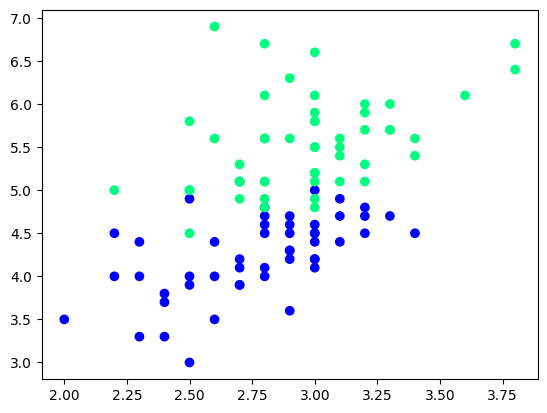

In [14]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['target'], cmap='winter')

In [15]:
df_train = df.iloc[:30, :].sample(10)
df_train

,sepal width (cm),petal length (cm),target
56,3.3,4.7,1
58,2.9,4.6,1
65,3.1,4.4,1
68,2.2,4.5,1
61,3.0,4.2,1
76,2.8,4.8,1
75,3.0,4.4,1
71,2.8,4.0,1
73,2.8,4.7,1
59,2.7,3.9,1


In [18]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[:80, :].sample(5)

In [19]:
df_train

,sepal width (cm),petal length (cm),target
110,3.2,5.1,2
136,3.4,5.6,2
118,2.6,6.9,2
86,3.1,4.7,1
54,2.8,4.6,1
138,3.0,4.8,2
111,2.7,5.3,2
95,3.0,4.2,1
130,2.8,6.1,2
72,2.5,4.9,1


In [20]:
df_val

,sepal width (cm),petal length (cm),target
51,3.2,4.5,1
63,2.9,4.7,1
117,3.8,6.7,2
82,2.7,3.9,1
84,3.0,4.5,1


In [21]:
df_test

,sepal width (cm),petal length (cm),target
133,2.8,5.1,2
58,2.9,4.6,1
102,3.0,5.9,2
113,2.5,5.0,2
126,2.8,4.8,2


In [22]:
X_test = df_val.iloc[:, 0:2]
y_test = df_val.iloc[:, -1]

## Case 1 -Bagging

In [23]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),target
72,2.5,4.9,1
130,2.8,6.1,2
138,3.0,4.8,2
110,3.2,5.1,2
54,2.8,4.6,1
54,2.8,4.6,1
86,3.1,4.7,1
72,2.5,4.9,1


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [26]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

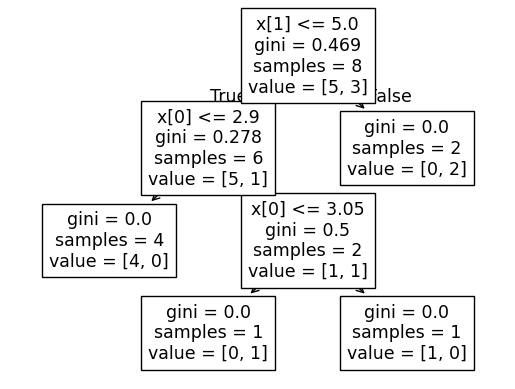

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


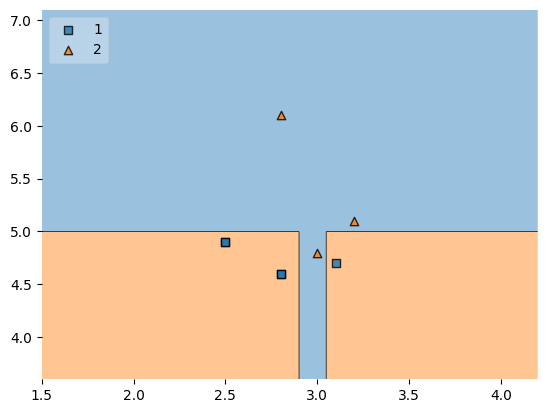

In [27]:
evaluate(dt_bag1,X,y)

In [28]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),target
110,3.2,5.1,2
86,3.1,4.7,1
95,3.0,4.2,1
111,2.7,5.3,2
130,2.8,6.1,2
86,3.1,4.7,1
118,2.6,6.9,2
136,3.4,5.6,2


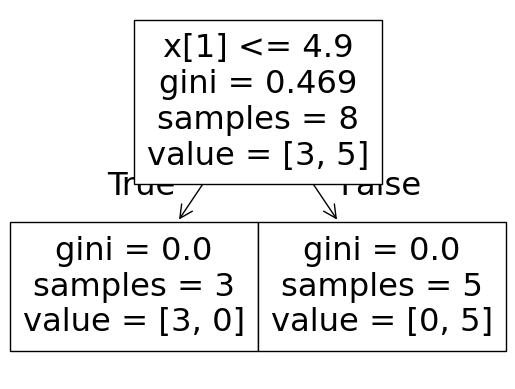

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


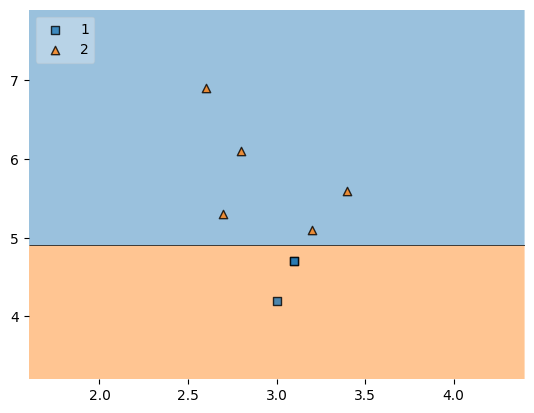

In [29]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [30]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),target
118,2.6,6.9,2
111,2.7,5.3,2
110,3.2,5.1,2
138,3.0,4.8,2
118,2.6,6.9,2
111,2.7,5.3,2
110,3.2,5.1,2
86,3.1,4.7,1


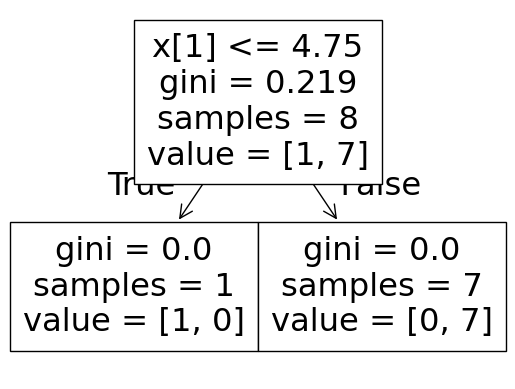

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


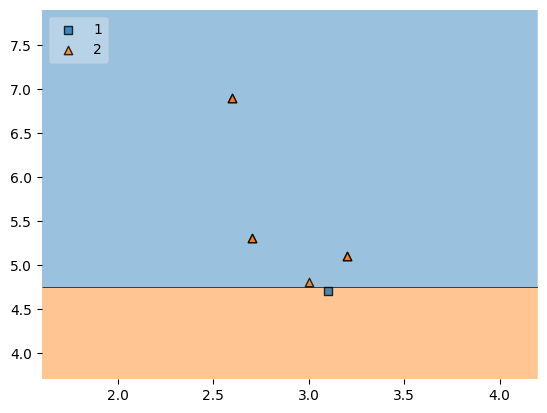

In [31]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [32]:
df_test

,sepal width (cm),petal length (cm),target
133,2.8,5.1,2
58,2.9,4.6,1
102,3.0,5.9,2
113,2.5,5.0,2
126,2.8,4.8,2


In [33]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [34]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),target
110,3.2,5.1,2
136,3.4,5.6,2
118,2.6,6.9,2
86,3.1,4.7,1
54,2.8,4.6,1
138,3.0,4.8,2
111,2.7,5.3,2
95,3.0,4.2,1
130,2.8,6.1,2
72,2.5,4.9,1


In [35]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
54,2.8,4.6,1
130,2.8,6.1,2
86,3.1,4.7,1
111,2.7,5.3,2
72,2.5,4.9,1
118,2.6,6.9,2
136,3.4,5.6,2
138,3.0,4.8,2


## Random Subspaces

In [40]:
df1 = load_iris(as_frame=True).frame
df1 = df1.sample(10)

In [41]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
83,6.0,2.7,5.1,1.6,1
36,5.5,3.5,1.3,0.2,0
109,7.2,3.6,6.1,2.5,2
26,5.0,3.4,1.6,0.4,0
143,6.8,3.2,5.9,2.3,2
53,5.5,2.3,4.0,1.3,1
147,6.5,3.0,5.2,2.0,2
119,6.0,2.2,5.0,1.5,2
120,6.9,3.2,5.7,2.3,2
126,6.2,2.8,4.8,1.8,2


In [46]:
df1.sample(2,replace=True,axis=1)

,sepal width (cm),petal width (cm)
83,2.7,1.6
36,3.5,0.2
109,3.6,2.5
26,3.4,0.4
143,3.2,2.3
53,2.3,1.3
147,3.0,2.0
119,2.2,1.5
120,3.2,2.3
126,2.8,1.8


## Random patches

In [47]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
83,6.0,2.7,5.1,1.6,1
36,5.5,3.5,1.3,0.2,0
109,7.2,3.6,6.1,2.5,2
26,5.0,3.4,1.6,0.4,0
143,6.8,3.2,5.9,2.3,2
53,5.5,2.3,4.0,1.3,1
147,6.5,3.0,5.2,2.0,2
119,6.0,2.2,5.0,1.5,2
120,6.9,3.2,5.7,2.3,2
126,6.2,2.8,4.8,1.8,2


In [48]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal length (cm),target
53,5.5,1
53,5.5,1
109,7.2,2
36,5.5,0
120,6.9,2
147,6.5,2
36,5.5,0
143,6.8,2


# Bagging Demo

In [49]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [50]:
X,y = make_classification(n_samples=10000, n_features=10,n_informative=3)

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

print("Decision Tree accuracy",accuracy_score(y_test,y_pred))

Decision Tree accuracy 0.902


## Bagging

In [54]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.5,
    bootstrap=True,
    random_state=42
)

In [55]:
bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.5,
                  n_estimators=500, random_state=42)

In [56]:
y_pred = bag.predict(X_test)

In [57]:
accuracy_score(y_test,y_pred)

0.939

In [61]:
bag.estimators_samples_[0].shape

(4000,)

In [59]:
bag.estimators_features_[0].shape

(10,)

## Bagging using SVM

In [62]:
bag = BaggingClassifier(
    estimator=SVC(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42
)

In [63]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Bagging using SVM",accuracy_score(y_test,y_pred))

Bagging using SVM 0.9325


## Pasting

In [64]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=False,
    random_state=42,
    verbose = 1,
    n_jobs=-1
)


In [65]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Pasting classifier",accuracy_score(y_test,y_pred))

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   11.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Pasting classifier 0.9365


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.2s finished


## Random Subspaces

In [67]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=1.0,
    bootstrap=False,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [68]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Subspaces classifier",accuracy_score(y_test,y_pred))

Random Subspaces classifier 0.9385


In [69]:
bag.estimators_samples_[0].shape

(8000,)

In [70]:
bag.estimators_features_[0].shape

(5,)

## Random patches

In [71]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [72]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Patches classifier",accuracy_score(y_test,y_pred))

Random Patches classifier 0.9335


## OOB Score

In [73]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

In [74]:
bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.25,
                  n_estimators=500, oob_score=True, random_state=42)

In [75]:
bag.oob_score_

0.94

In [76]:
y_pred = bag.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.9385


## Bagging Tips
*   Bagging generally gives better results than Pasting
*   Good results come around the 25% to 50% row sampling mark
*   Random patches and subspaces should be used while dealing with high dimensional data
*   To find the correct hyperparameter values we can do GridSearchCV/RandomSearchCV

## Applying GridSearchCV

In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
parameters = {
    'n_estimators': [50,100,500],
    'max_samples': [0.1,0.4,0.7,1.0],
    'bootstrap' : [True,False],
    'max_features' : [0.1,0.4,0.7,1.0]
    }

In [79]:
search = GridSearchCV(BaggingClassifier(), parameters, cv=5)

In [80]:
search.fit(X_train,y_train)

KeyboardInterrupt: 

In [ ]:
search.best_score_

In [ ]:
search.best_params_

# Bagging Regression

In [1]:
from sklearn import datasets

housing = datasets.fetch_california_housing()
X_boston, Y_boston = housing.data, housing.target
print('Dataset features names : '+ str(housing.feature_names))
print('Dataset features size : '+ str(housing.data.shape))
print('Dataset target size : '+ str(housing.target.shape))

Dataset features names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset features size : (20640, 8)
Dataset target size : (20640,)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_boston, Y_boston , train_size=0.80, test_size=0.20, random_state=123)
print('Train/Test Sets Sizes : ',X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

Train/Test Sets Sizes :  (16512, 8) (4128, 8) (16512,) (4128,)


In [4]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
knn = KNeighborsRegressor()

In [5]:
lr.fit(X_train,Y_train)
dt.fit(X_train,Y_train)
knn.fit(X_train,Y_train)

KNeighborsRegressor()

In [6]:
y_pred1 = lr.predict(X_test)
y_pred2 = dt.predict(X_test)
y_pred3 = knn.predict(X_test)

In [7]:
print("R^2 score for LR",r2_score(Y_test,y_pred1))
print("R^2 score for DT",r2_score(Y_test,y_pred2))
print("R^2 score for KNN",r2_score(Y_test,y_pred3))

R^2 score for LR 0.6104546894797869
R^2 score for DT 0.594756724096764
R^2 score for KNN 0.16261917827057237


In [8]:
from sklearn.ensemble import BaggingRegressor

bag_regressor = BaggingRegressor(random_state=1)
bag_regressor.fit(X_train, Y_train)

BaggingRegressor(random_state=1)

In [9]:
Y_preds = bag_regressor.predict(X_test)

print('Training Coefficient of R^2 : %.3f'%bag_regressor.score(X_train, Y_train))
print('Test Coefficient of R^2 : %.3f'%bag_regressor.score(X_test, Y_test))

Training Coefficient of R^2 : 0.963
Test Coefficient of R^2 : 0.792


In [ ]:
%%time

n_samples = housing.data.shape[0]
n_features = housing.data.shape[1]

params = {'estimator': [None, LinearRegression(), KNeighborsRegressor()],
          'n_estimators': [20,50,100],
          'max_samples': [0.5,1.0],
          'max_features': [0.5,1.0],
          'bootstrap': [True, False],
          'bootstrap_features': [True, False]}

bagging_regressor_grid = GridSearchCV(BaggingRegressor(random_state=1, n_jobs=-1), param_grid =params, cv=3, n_jobs=-1, verbose=1)
bagging_regressor_grid.fit(X_train, Y_train)

print('Train R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_train, Y_train))
print('Test R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_test, Y_test))
print('Best R^2 Score Through Grid Search : %.3f'%bagging_regressor_grid.best_score_)
print('Best Parameters : ',bagging_regressor_grid.best_params_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
